In [ ]:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [ ]:
# Load data

url = "https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv"
df = pd.read_csv(url)

print(f"Dataset loaded: {len(df)} samples")

Dataset loaded: 24783 samples


In [ ]:
# Davidson: 0=hate, 1=offensive, 2=neither → Binary: 0=not hate, 1=hate
def convert_to_binary(label):
    return 1 if label in [0, 1] else 0

df['label'] = df['class'].apply(convert_to_binary)
df = df[['tweet', 'label']].dropna()
df = df.rename(columns={'tweet': 'text'})

print(f"\nBinary labels: 0=Not Hate, 1=Hate")
print(df['label'].value_counts())


Binary labels: 0=Not Hate, 1=Hate
label
1    20620
0     4163
Name: count, dtype: int64


In [ ]:
# Train/test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df.reset_index(drop=True)),
    'test': Dataset.from_pandas(test_df.reset_index(drop=True))
})

print(f"\nTrain: {len(train_df)}, Test: {len(test_df)}")



Train: 19826, Test: 4957


In [ ]:
# Tokenizer and model
model_name = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=128)

tokenized_ds = dataset.map(tokenize_fn, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

Map:   0%|          | 0/19826 [00:00<?, ? examples/s]

Map:   0%|          | 0/4957 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:


# Training
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir="./english_hate_model",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["test"],
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.118503,0.113437,0.961469
2,0.131403,0.123334,0.961267
3,0.062287,0.150766,0.964091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3720, training_loss=0.11240614152723744, metrics={'train_runtime': 2423.6785, 'train_samples_per_second': 24.54, 'train_steps_per_second': 1.535, 'total_flos': 3912364964906496.0, 'train_loss': 0.11240614152723744, 'epoch': 3.0})

In [ ]:
# Evaluate
results = trainer.evaluate()

print(f"\n{'='*60}")
print(f"RESULTS")
print(f"{'='*60}")
print(f"Accuracy: {results['eval_accuracy']:.3f}")

predictions = trainer.predict(tokenized_ds['test'])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=['Not Hate', 'Hate']))


RESULTS
Accuracy: 0.964

Classification Report:
              precision    recall  f1-score   support

    Not Hate       0.90      0.89      0.89       833
        Hate       0.98      0.98      0.98      4124

    accuracy                           0.96      4957
   macro avg       0.94      0.93      0.94      4957
weighted avg       0.96      0.96      0.96      4957



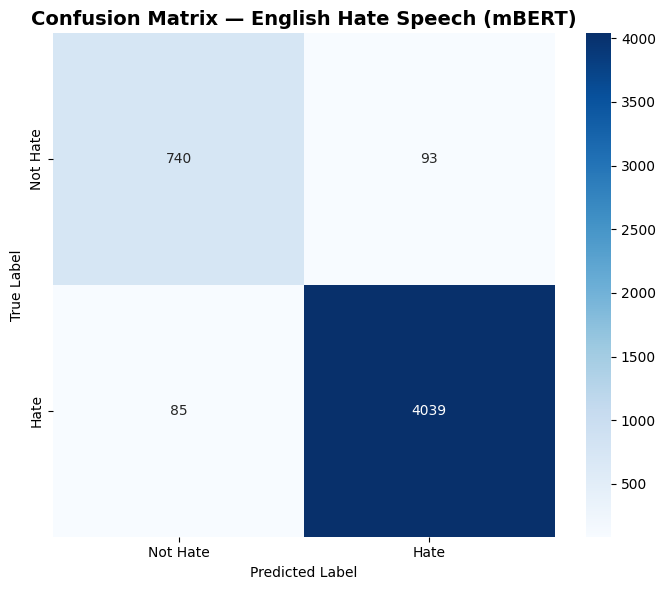

✅ Saved → confusion_matrix.png


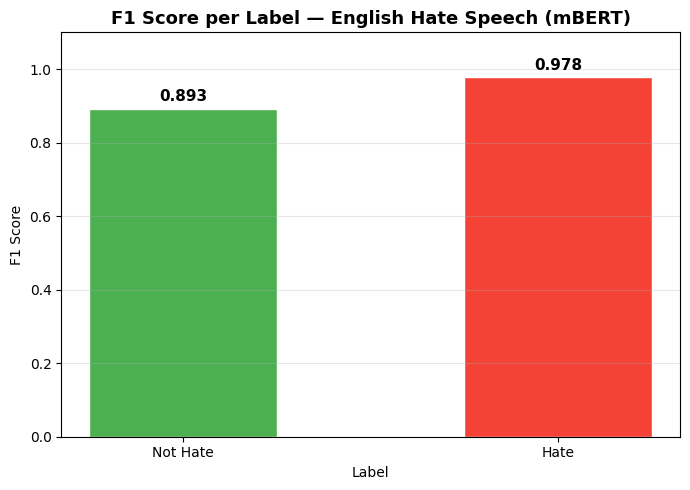

✅ Saved → f1_per_label.png


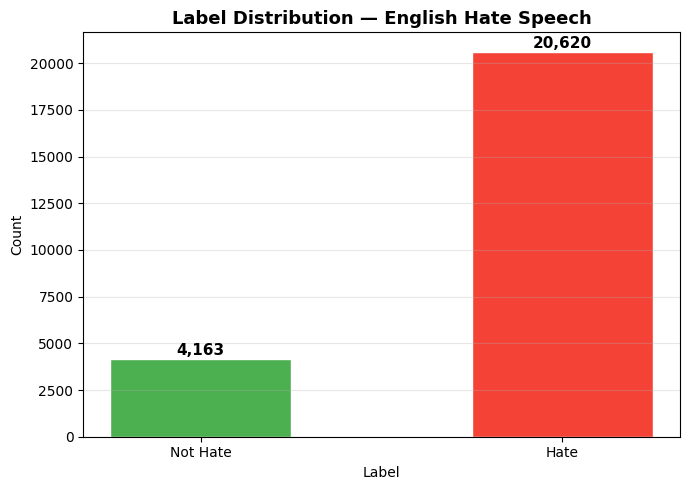

✅ Saved → label_distribution.png


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to: ./final_english_model
✅ Checkpoints: ./english_hate_model



In [ ]:
#visualisation

 #Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Hate', 'Hate'],
            yticklabels=['Not Hate', 'Hate'])
plt.title('Confusion Matrix — English Hate Speech (mBERT)', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved → confusion_matrix.png")

# F1 Score per Label
f1_scores = f1_score(true_labels, pred_labels, average=None)
labels = ['Not Hate', 'Hate']
colors = ['#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, f1_scores, color=colors, edgecolor='white', width=0.5)
ax.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{score:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_title('F1 Score per Label — English Hate Speech (mBERT)', fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Label')
plt.tight_layout()
plt.savefig('f1_per_label.png', dpi=150)
plt.show()
print("✅ Saved → f1_per_label.png")

# Label Distribution
label_counts = df['label'].value_counts().sort_index()
labels_names = ['Not Hate', 'Hate']
colors = ['#4CAF50', '#F44336']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels_names, label_counts.values, color=colors, edgecolor='white', width=0.5)
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, label_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Label Distribution — English Hate Speech', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Label')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()
print("✅ Saved → label_distribution.png")

#save

trainer.save_model("./final_english_model")
tokenizer.save_pretrained("./final_english_model")

print(f"\n{'='*60}")
print(f"✅ Model saved to: ./final_english_model")
print(f"✅ Checkpoints: ./english_hate_model")
print(f"{'='*60}\n")